In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from typing import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report)
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

In [49]:
np.random.seed(42)

FEATURE_COLS = ['Monthly_Spend_USD', 'Support_Tickets_30D', 'Days_Since_Last_Login', 'Contract_Length_Months']

# =====================================================================
# 1. BASELINE DATASET (Clean but Realistic - 200 rows)
# - Tendencia clara pero con un 5% de solapamiento natural en las métricas.
# =====================================================================
n_base = 200
n_0, n_1 = 100, 100

# Retained (0): Mayor gasto, menos soporte, logins recientes, contratos más largos
spend_0 = np.random.normal(4200, 1200, n_0).clip(200, 12000)
tickets_0 = np.random.poisson(1.8, n_0)
login_0 = np.random.gamma(shape=2, scale=3, size=n_0)  # Sesgado a pocos días
contract_0 = np.random.choice([6, 12, 24], size=n_0, p=[0.2, 0.5, 0.3])

# Churned (1): Menor gasto, más soporte, alta inactividad, contratos cortos
spend_1 = np.random.normal(1800, 900, n_1).clip(50, 8000)
tickets_1 = np.random.poisson(5.5, n_1)
login_1 = np.random.uniform(10, 45, n_1)
contract_1 = np.random.choice([1, 3, 6, 12], size=n_1, p=[0.5, 0.3, 0.1, 0.1])

df_clean = pd.DataFrame({
    'Monthly_Spend_USD': np.concatenate([spend_0, spend_1]),
    'Support_Tickets_30D': np.concatenate([tickets_0, tickets_1]),
    'Days_Since_Last_Login': np.concatenate([login_0, login_1]),
    'Contract_Length_Months': np.concatenate([contract_0, contract_1]),
    'Churn': [0] * n_0 + [1] * n_1
}).round(2)

# Volteo voluntario del 4% de etiquetas para emular 'ruido aleatorio real'
flip_idx = np.random.choice(df_clean.index, size=8, replace=False)
df_clean.loc[flip_idx, 'Churn'] = 1 - df_clean.loc[flip_idx, 'Churn']


# =====================================================================
# 2. SEVERELY IMBALANCED DATASET (90% Retained, 10% Churned - 200 rows)
# - 180 Retained vs 20 Churned con solapamiento parcial en patrones.
# =====================================================================
n_maj, n_min = 180, 20

df_imbalanced = pd.DataFrame({
    'Monthly_Spend_USD': np.concatenate([
        np.random.normal(3800, 1400, n_maj).clip(100, 15000),
        np.random.normal(1500, 800, n_min).clip(50, 5000)
    ]),
    'Support_Tickets_30D': np.concatenate([
        np.random.poisson(2.1, n_maj),
        np.random.poisson(6.8, n_min)
    ]),
    'Days_Since_Last_Login': np.concatenate([
        np.random.gamma(2.5, 3.5, n_maj),
        np.random.uniform(15, 50, n_min)
    ]),
    'Contract_Length_Months': np.concatenate([
        np.random.choice([1, 3, 6, 12, 24], n_maj, p=[0.1, 0.15, 0.25, 0.35, 0.15]),
        np.random.choice([1, 3, 6], n_min, p=[0.6, 0.3, 0.1])
    ]),
    'Churn': [0] * n_maj + [1] * n_min
}).round(2)


# =====================================================================
# 3. EXTREME OUTLIERS DATASET (200 rows)
# - 5-6 registros con errores de digitación, cuentas corporativas gigantes
#   y cuentas 'zombie' con inactividad extrema.
# =====================================================================
df_outliers = df_clean.copy()

# Anomalías de negocio / errores de log
df_outliers.loc[5, 'Monthly_Spend_USD'] = 280000.00   # Cuenta Enterprise / Whale gigantesca
df_outliers.loc[18, 'Support_Tickets_30D'] = 142       # Error de API enviando miles de pings como tickets
df_outliers.loc[42, 'Days_Since_Last_Login'] = 680.00  # Cuenta legacy congelada
df_outliers.loc[110, 'Monthly_Spend_USD'] = 0.01       # Error de facturación / saldo residual
df_outliers.loc[135, 'Support_Tickets_30D'] = 95       # Ataque de spam en portal de soporte
df_outliers.loc[175, 'Days_Since_Last_Login'] = 410.00  # Usuario dado de baja administrativamente sin actualizar status


# =====================================================================
# 4. HIGH ENTROPY / HIGH NOISE DATASET (200 rows)
# - Comportamientos casi impredecibles; la tasa de Churn depende de factores no medidos.
# =====================================================================
n_noise = 200

# Las características tienen poca correlación implícita con el target
spend_h = np.random.normal(3000, 1800, n_noise).clip(50, 10000)
tickets_h = np.random.poisson(3.8, n_noise)
login_h = np.random.uniform(1, 40, n_noise)
contract_h = np.random.choice([1, 3, 6, 12, 24], n_noise)

# Probabilidad de Churn influenciada ligeramente por el azar (65% ruido, 35% señal)
logits = -0.0001 * spend_h + 0.1 * tickets_h + 0.02 * login_h + np.random.normal(0, 1.2, n_noise)
probs = 1 / (1 + np.exp(-logits))
churn_high_entropy = (probs > 0.5).astype(int)

df_high_entropy = pd.DataFrame({
    'Monthly_Spend_USD': spend_h,
    'Support_Tickets_30D': tickets_h,
    'Days_Since_Last_Login': login_h,
    'Contract_Length_Months': contract_h,
    'Churn': churn_high_entropy
}).round(2)


# =====================================================================
# 5. LOW ENTROPY DATASET (200 rows)
# - Reglas deterministas semi-claras, pero agregando 3% de excepciones de negocio.
# =====================================================================
n_low_ent = 200

spend_l = np.random.uniform(300, 12000, n_low_ent)
tickets_l = np.random.poisson(3, n_low_ent)
inactivity_l = np.random.uniform(1, 60, n_low_ent)
contract_l = np.random.choice([1, 3, 6, 12, 24], n_low_ent)

# Regla base: Inactividad > 25 Y Contrato <= 3 meses
rule_churn = ((inactivity_l > 25) & (contract_l <= 3)).astype(int)

# Excepción de negocio: Si el gasto es muy alto (> $8000), el cliente NO se va (Account Manager dedicado)
rule_churn[spend_l > 8000] = 0

# Agregar un 3% de ruido aleatorio (excepciones no documentadas)
noise_idx = np.random.choice(n_low_ent, size=6, replace=False)
rule_churn[noise_idx] = 1 - rule_churn[noise_idx]

df_low_entropy = pd.DataFrame({
    'Monthly_Spend_USD': spend_l,
    'Support_Tickets_30D': tickets_l,
    'Days_Since_Last_Login': inactivity_l,
    'Contract_Length_Months': contract_l,
    'Churn': rule_churn
}).round(2)


# =====================================================================
# 6. SKEWED FEATURE DISTRIBUTION DATASET (200 rows)
# - Distribuciones Log-Normales marcadas en Spend y Logins.
# =====================================================================
n_skewed = 200
half = n_skewed // 2

# Log-Normales con varianza alta típicas de startups/SaaS (muchos de $10 y muy pocos de $10,000)
spend_skew = np.concatenate([
    np.random.lognormal(mean=8.2, sigma=0.9, size=half),  # Retained
    np.random.lognormal(mean=6.8, sigma=1.1, size=half)   # Churned
])

login_skew = np.concatenate([
    np.random.lognormal(mean=1.2, sigma=0.6, size=half),  # Retained (Logins muy recientes)
    np.random.lognormal(mean=3.2, sigma=0.7, size=half)   # Churned (Inactividad más larga)
])

df_skewed = pd.DataFrame({
    'Monthly_Spend_USD': spend_skew.clip(20, 50000),
    'Support_Tickets_30D': np.concatenate([np.random.poisson(1.5, half), np.random.poisson(5.2, half)]),
    'Days_Since_Last_Login': login_skew.clip(1, 120),
    'Contract_Length_Months': np.random.choice([1, 3, 6, 12, 24], size=n_skewed, p=[0.3, 0.2, 0.2, 0.15, 0.15]),
    'Churn': [0] * half + [1] * half
}).round(2)

# Permutar orden para no dejar las clases ordenadas perfectamente en el índice
df_skewed = df_skewed.sample(frac=1, random_state=42).reset_index(drop=True)


# =====================================================================
# 7. NON-LINEAR INTERACTION / XOR DATASET (200 rows)
# - Churn si: (High Spend Y Short Contract) O (Low Spend Y Long Contract)
# - Con solapamiento en las fronteras continuas para mayor realismo.
# =====================================================================
n_xor = 200

# Generar variables categóricas latentes
spend_high = np.random.choice([1, 0], size=n_xor, p=[0.5, 0.5])
contract_short = np.random.choice([1, 0], size=n_xor, p=[0.5, 0.5])

# Patrón XOR implícito
y_xor = (spend_high ^ contract_short)

# Mapear a valores continuos con dispersión para evitar "clusters" perfectos
spend_val = np.where(spend_high == 1, 
                     np.random.normal(7000, 1800, n_xor), 
                     np.random.normal(1500, 600, n_xor)).clip(100, 14000)

contract_val = np.where(contract_short == 1, 
                        np.random.choice([1, 3], size=n_xor), 
                        np.random.choice([12, 24], size=n_xor))

# Agregar ruido moderado a la etiqueta (7% de interferencia)
flip_xor = np.random.choice(n_xor, size=14, replace=False)
y_xor[flip_xor] = 1 - y_xor[flip_xor]

df_xor = pd.DataFrame({
    'Monthly_Spend_USD': spend_val,
    'Support_Tickets_30D': np.random.poisson(3.0, n_xor),
    'Days_Since_Last_Login': np.random.uniform(2, 25, n_xor),
    'Contract_Length_Months': contract_val,
    'Churn': y_xor
}).round(2)

# df Clean

In [50]:
df_clean.sample(4)

,Monthly_Spend_USD,Support_Tickets_30D,Days_Since_Last_Login,Contract_Length_Months,Churn
179,1190.19,3,12.37,3,1
157,2567.02,5,44.57,1,1
23,2490.30,0,3.96,6,0
161,2943.11,5,24.99,3,1


-------Report-------
              precision    recall  f1-score   support

    Retained       0.93      0.90      0.92        30
     Churned       0.90      0.93      0.92        30

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60



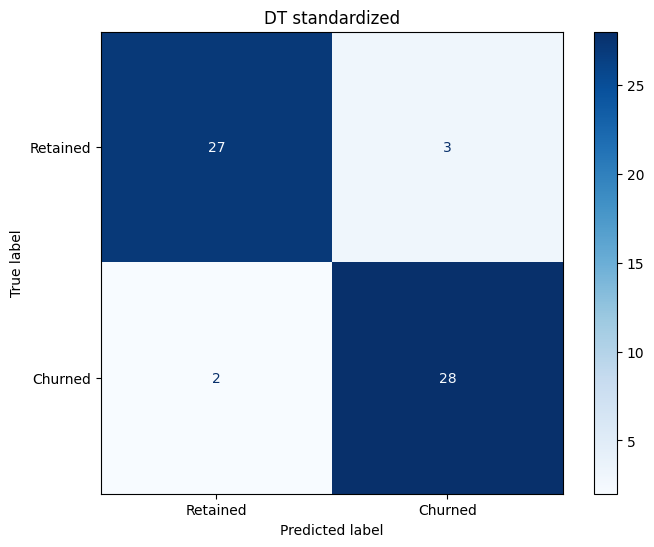

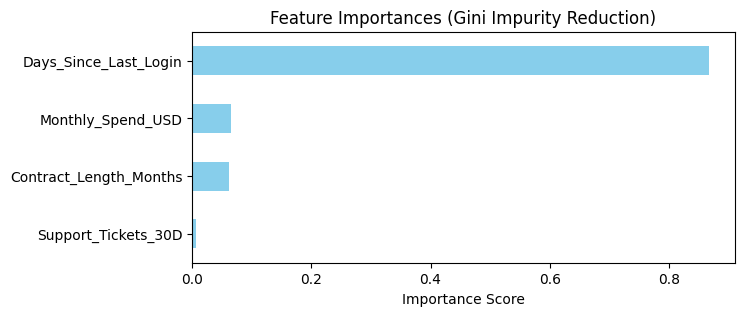


Training Accuracy: 97.14%
Testing Accuracy:  91.67%
Tree Depth: 3 | Total Leaves: 7

=== DECISION TREE RULES ===
|--- Days_Since_Last_Login <= -0.34
|   |--- Contract_Length_Months <= -0.53
|   |   |--- class: 1
|   |--- Contract_Length_Months >  -0.53
|   |   |--- Contract_Length_Months <= 1.33
|   |   |   |--- class: 0
|   |   |--- Contract_Length_Months >  1.33
|   |   |   |--- class: 0
|--- Days_Since_Last_Login >  -0.34
|   |--- Monthly_Spend_USD <= 0.45
|   |   |--- Support_Tickets_30D <= 2.08
|   |   |   |--- class: 1
|   |   |--- Support_Tickets_30D >  2.08
|   |   |   |--- class: 1
|   |--- Monthly_Spend_USD >  0.45
|   |   |--- Days_Since_Last_Login <= 0.12
|   |   |   |--- class: 0
|   |   |--- Days_Since_Last_Login >  0.12
|   |   |   |--- class: 1



In [61]:
TARGET = 'Churn'

FEATURES_X = [
    'Monthly_Spend_USD',
    'Support_Tickets_30D',
    'Days_Since_Last_Login',
    'Contract_Length_Months',
]

X, y = df_clean[FEATURES_X], df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3, stratify=y)

pipeline_scaled = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('decisiontree',DecisionTreeClassifier(max_depth=3, max_features=4, random_state=42))
])

pipeline_scaled.fit(X_train, y_train)
pipeline_scaled.predict((X_test))
y_pred = pipeline_scaled.predict(X_test)

print('-------Report-------')
print(classification_report(y_test, y_pred,target_names=['Retained', 'Churned']))

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned'],
).plot(ax=ax, cmap='Blues')

plt.title('DT standardized')
plt.show()


# Feature importance
tree_model = pipeline_scaled.named_steps['decisiontree']
importances = pd.Series(
    tree_model.feature_importances_,
    index=FEATURES_X
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
importances.plot(kind='barh', color='skyblue', ax=ax)
ax.invert_yaxis()
plt.title('Feature Importances (Gini Impurity Reduction)')
plt.xlabel('Importance Score')
plt.show()

# Overfitting inspect
train_acc = pipeline_scaled.score(X_train, y_train)
test_acc = pipeline_scaled.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy:  {test_acc:.2%}")
print(f"Tree Depth: {tree_model.get_depth()} | Total Leaves: {tree_model.get_n_leaves()}")

print("\n=== DECISION TREE RULES ===")
print(export_text(tree_model, feature_names=FEATURES_X))

In this example, df_clean simulates perfect data "only in our dreams we could find it", where the Decisiontree model can easily find the optimal split

# df Imbalanced

-------Report-------
              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00        54
     Churned       1.00      1.00      1.00         6

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



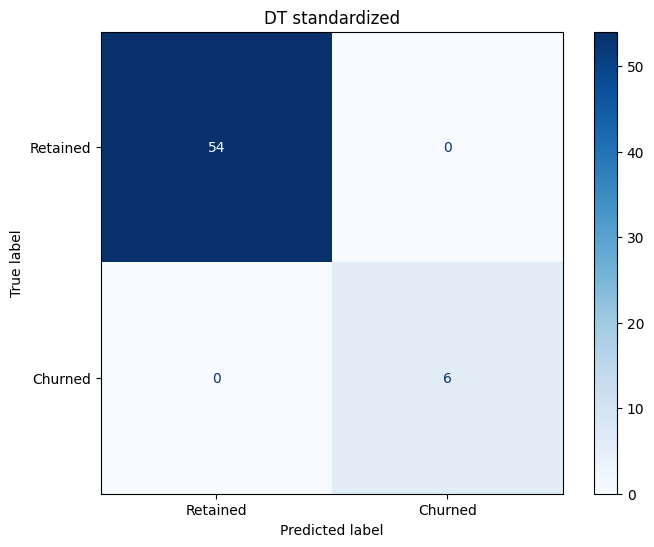

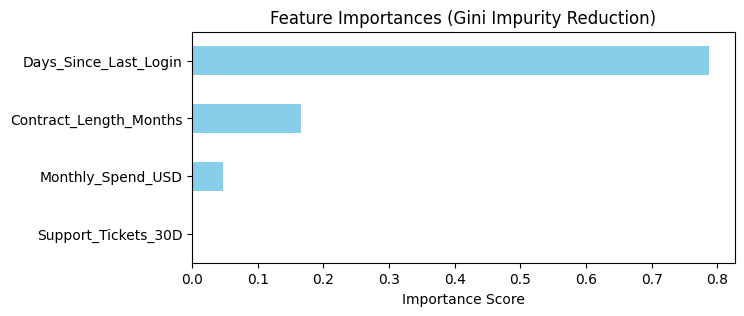


Training Accuracy: 100.00%
Testing Accuracy:  100.00%
Tree Depth: 3 | Total Leaves: 6

=== DECISION TREE RULES ===
|--- Days_Since_Last_Login <= 0.43
|   |--- Contract_Length_Months <= -1.11
|   |   |--- class: 0
|   |--- Contract_Length_Months >  -1.11
|   |   |--- class: 0
|--- Days_Since_Last_Login >  0.43
|   |--- Contract_Length_Months <= -0.08
|   |   |--- Monthly_Spend_USD <= -0.69
|   |   |   |--- class: 1
|   |   |--- Monthly_Spend_USD >  -0.69
|   |   |   |--- class: 0
|   |--- Contract_Length_Months >  -0.08
|   |   |--- Contract_Length_Months <= 1.23
|   |   |   |--- class: 0
|   |   |--- Contract_Length_Months >  1.23
|   |   |   |--- class: 0



In [66]:
TARGET = 'Churn'

FEATURES_X = [
    'Monthly_Spend_USD',
    'Support_Tickets_30D',
    'Days_Since_Last_Login',
    'Contract_Length_Months',
]

X, y = df_imbalanced[FEATURES_X], df_imbalanced[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3, stratify=y)

pipeline_scaled = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('decisiontree',DecisionTreeClassifier(max_depth=3, max_features=2, random_state=42,class_weight='balanced'))
])

pipeline_scaled.fit(X_train, y_train)
pipeline_scaled.predict((X_test))
y_pred = pipeline_scaled.predict(X_test)

print('-------Report-------')
print(classification_report(y_test, y_pred,target_names=['Retained', 'Churned']))

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned'],
).plot(ax=ax, cmap='Blues')

plt.title('DT standardized')
plt.show()


# Feature importance
tree_model = pipeline_scaled.named_steps['decisiontree']
importances = pd.Series(
    tree_model.feature_importances_,
    index=FEATURES_X
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
importances.plot(kind='barh', color='skyblue', ax=ax)
ax.invert_yaxis()
plt.title('Feature Importances (Gini Impurity Reduction)')
plt.xlabel('Importance Score')
plt.show()

# Overfitting inspect
train_acc = pipeline_scaled.score(X_train, y_train)
test_acc = pipeline_scaled.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy:  {test_acc:.2%}")
print(f"Tree Depth: {tree_model.get_depth()} | Total Leaves: {tree_model.get_n_leaves()}")

print("\n=== DECISION TREE RULES ===")
print(export_text(tree_model, feature_names=FEATURES_X))

df_imbalanced is the perfect example for demostrating how the decision tree model handle severy imbalanced target, (1:20 - 0:180).Specifying  stratify=y during the train test split is critical, as it ensures both splits mantain the exact same class proportions as the original df and decision trees are robust to monotonic feature scales though they still tend to favor the majority class unless tuned using parameters like class_weight='balanced'

# df Outliers

-------Report-------
              precision    recall  f1-score   support

    Retained       0.96      0.80      0.87        30
     Churned       0.83      0.97      0.89        30

    accuracy                           0.88        60
   macro avg       0.89      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



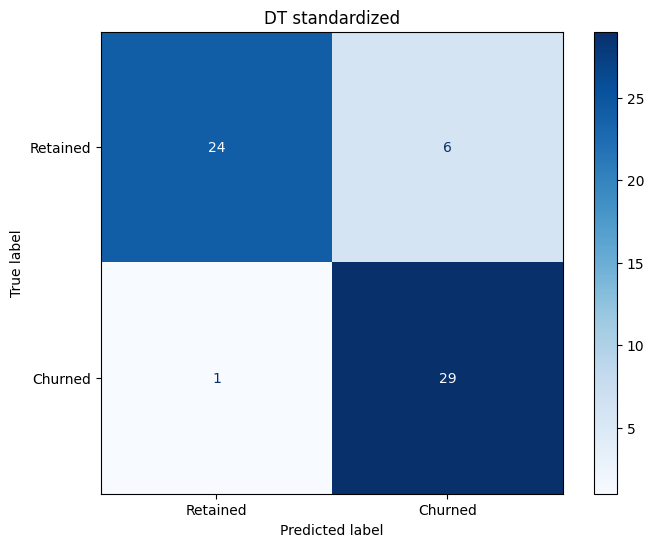

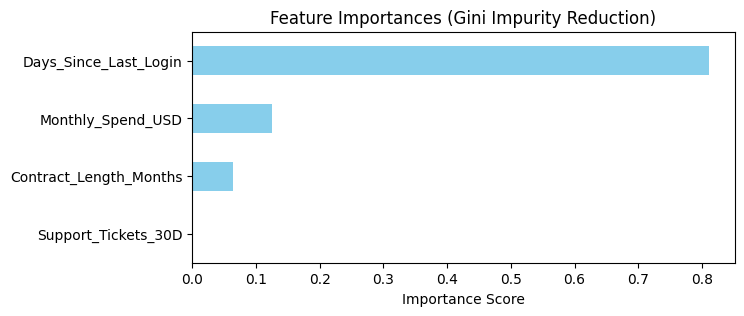


Training Accuracy: 95.71%
Testing Accuracy:  88.33%
Tree Depth: 3 | Total Leaves: 7

=== DECISION TREE RULES ===
|--- Days_Since_Last_Login <= -0.18
|   |--- Contract_Length_Months <= -0.53
|   |   |--- class: 1
|   |--- Contract_Length_Months >  -0.53
|   |   |--- Contract_Length_Months <= 1.33
|   |   |   |--- class: 0
|   |   |--- Contract_Length_Months >  1.33
|   |   |   |--- class: 0
|--- Days_Since_Last_Login >  -0.18
|   |--- Monthly_Spend_USD <= -0.06
|   |   |--- Days_Since_Last_Login <= -0.05
|   |   |   |--- class: 1
|   |   |--- Days_Since_Last_Login >  -0.05
|   |   |   |--- class: 1
|   |--- Monthly_Spend_USD >  -0.06
|   |   |--- Monthly_Spend_USD <= -0.03
|   |   |   |--- class: 0
|   |   |--- Monthly_Spend_USD >  -0.03
|   |   |   |--- class: 1



In [68]:
TARGET = 'Churn'

FEATURES_X = [
    'Monthly_Spend_USD',
    'Support_Tickets_30D',
    'Days_Since_Last_Login',
    'Contract_Length_Months',
]

X, y = df_outliers[FEATURES_X], df_outliers[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3, stratify=y)

pipeline_scaled = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('decisiontree',DecisionTreeClassifier(max_depth=3, max_features=2, random_state=42))
])

pipeline_scaled.fit(X_train, y_train)
pipeline_scaled.predict((X_test))
y_pred = pipeline_scaled.predict(X_test)

print('-------Report-------')
print(classification_report(y_test, y_pred,target_names=['Retained', 'Churned']))

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned'],
).plot(ax=ax, cmap='Blues')

plt.title('DT standardized')
plt.show()


# Feature importance
tree_model = pipeline_scaled.named_steps['decisiontree']
importances = pd.Series(
    tree_model.feature_importances_,
    index=FEATURES_X
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
importances.plot(kind='barh', color='skyblue', ax=ax)
ax.invert_yaxis()
plt.title('Feature Importances (Gini Impurity Reduction)')
plt.xlabel('Importance Score')
plt.show()

# Overfitting inspect
train_acc = pipeline_scaled.score(X_train, y_train)
test_acc = pipeline_scaled.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy:  {test_acc:.2%}")
print(f"Tree Depth: {tree_model.get_depth()} | Total Leaves: {tree_model.get_n_leaves()}")

print("\n=== DECISION TREE RULES ===")
print(export_text(tree_model, feature_names=FEATURES_X))

Df_outliers represents data with extreme feature values, when it comes to decision tree, the model handles this kind of problems naturally, as rule-based split are based in order (entropy) rather than absolute distances

# df High entropy

-------Report-------
              precision    recall  f1-score   support

    Retained       0.45      0.43      0.44        21
     Churned       0.70      0.72      0.71        39

    accuracy                           0.62        60
   macro avg       0.57      0.57      0.57        60
weighted avg       0.61      0.62      0.61        60



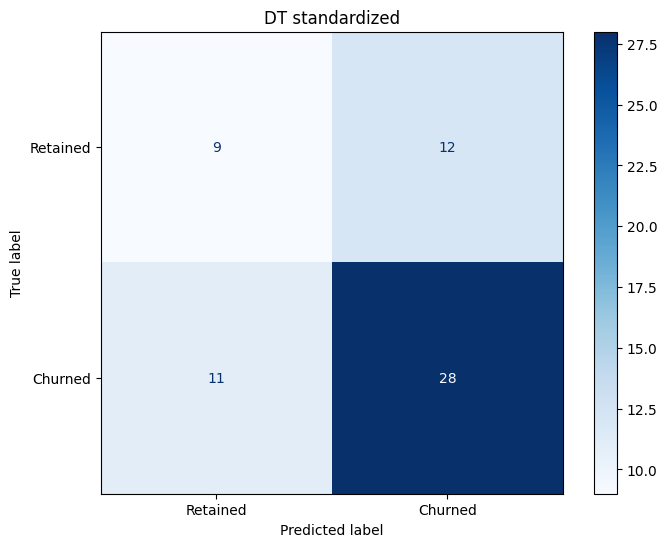

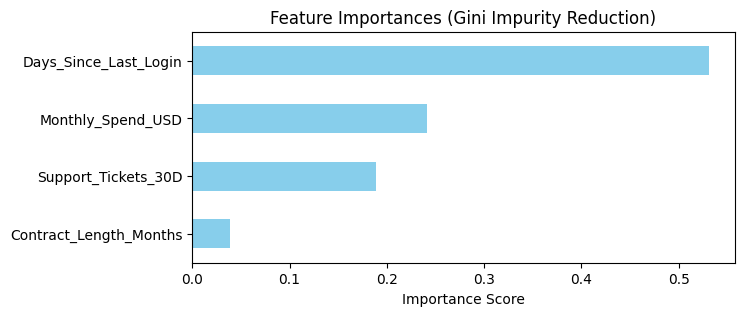


Training Accuracy: 77.86%
Testing Accuracy:  61.67%
Tree Depth: 4 | Total Leaves: 15

=== DECISION TREE RULES ===
|--- Days_Since_Last_Login <= 0.64
|   |--- Days_Since_Last_Login <= -0.89
|   |   |--- Support_Tickets_30D <= -0.04
|   |   |   |--- Monthly_Spend_USD <= -1.29
|   |   |   |   |--- class: 0
|   |   |   |--- Monthly_Spend_USD >  -1.29
|   |   |   |   |--- class: 1
|   |   |--- Support_Tickets_30D >  -0.04
|   |   |   |--- Monthly_Spend_USD <= -0.64
|   |   |   |   |--- class: 1
|   |   |   |--- Monthly_Spend_USD >  -0.64
|   |   |   |   |--- class: 0
|   |--- Days_Since_Last_Login >  -0.89
|   |   |--- Days_Since_Last_Login <= 0.48
|   |   |   |--- Support_Tickets_30D <= -0.52
|   |   |   |   |--- class: 0
|   |   |   |--- Support_Tickets_30D >  -0.52
|   |   |   |   |--- class: 1
|   |   |--- Days_Since_Last_Login >  0.48
|   |   |   |--- Monthly_Spend_USD <= -0.75
|   |   |   |   |--- class: 1
|   |   |   |--- Monthly_Spend_USD >  -0.75
|   |   |   |   |--- class: 0
|---

In [54]:
TARGET = 'Churn'

FEATURES_X = [
    'Monthly_Spend_USD',
    'Support_Tickets_30D',
    'Days_Since_Last_Login',
    'Contract_Length_Months',
]

X, y = df_high_entropy[FEATURES_X], df_high_entropy[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3, stratify=y)

pipeline_scaled = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('decisiontree',DecisionTreeClassifier(max_depth=4, random_state=42))
])

pipeline_scaled.fit(X_train, y_train)
pipeline_scaled.predict((X_test))
y_pred = pipeline_scaled.predict(X_test)

print('-------Report-------')
print(classification_report(y_test, y_pred,target_names=['Retained', 'Churned']))

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned'],
).plot(ax=ax, cmap='Blues')

plt.title('DT standardized')
plt.show()


# Feature importance
tree_model = pipeline_scaled.named_steps['decisiontree']
importances = pd.Series(
    tree_model.feature_importances_,
    index=FEATURES_X
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
importances.plot(kind='barh', color='skyblue', ax=ax)
ax.invert_yaxis()
plt.title('Feature Importances (Gini Impurity Reduction)')
plt.xlabel('Importance Score')
plt.show()

# Overfitting inspect
train_acc = pipeline_scaled.score(X_train, y_train)
test_acc = pipeline_scaled.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy:  {test_acc:.2%}")
print(f"Tree Depth: {tree_model.get_depth()} | Total Leaves: {tree_model.get_n_leaves()}")

print("\n=== DECISION TREE RULES ===")
print(export_text(tree_model, feature_names=FEATURES_X))

df_high_entropy is the perfect example for demostrating when the data do not follow any pattern and the values are random, the model can not predict anything, because information entropy is high, the model can not identify any splits that meaningfully reduce impurity

# df Lowe entropy

In [69]:
df_low_entropy.Churn.value_counts()

Churn
0    163
1     37
Name: count, dtype: int64

-------Report-------
              precision    recall  f1-score   support

    Retained       0.96      1.00      0.98        49
     Churned       1.00      0.82      0.90        11

    accuracy                           0.97        60
   macro avg       0.98      0.91      0.94        60
weighted avg       0.97      0.97      0.97        60



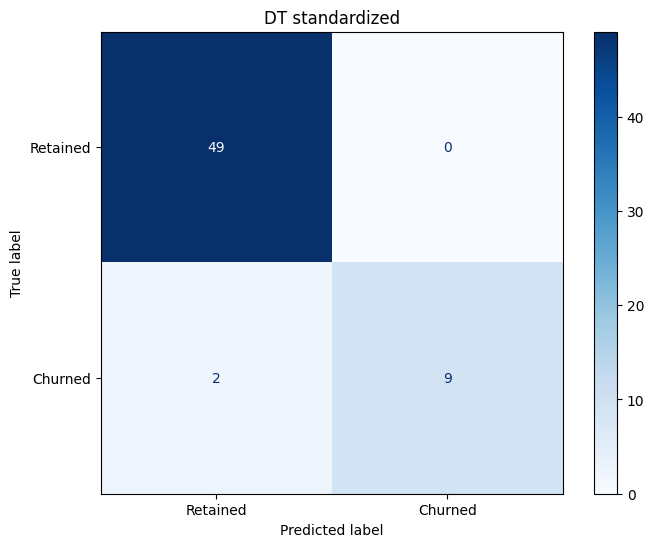

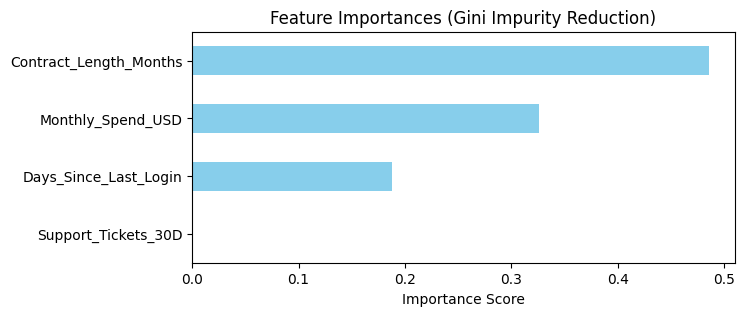


Training Accuracy: 98.57%
Testing Accuracy:  96.67%
Tree Depth: 4 | Total Leaves: 11

=== DECISION TREE RULES ===
|--- Contract_Length_Months <= -0.61
|   |--- Monthly_Spend_USD <= 0.54
|   |   |--- Days_Since_Last_Login <= -0.42
|   |   |   |--- class: 0
|   |   |--- Days_Since_Last_Login >  -0.42
|   |   |   |--- Monthly_Spend_USD <= -1.46
|   |   |   |   |--- class: 1
|   |   |   |--- Monthly_Spend_USD >  -1.46
|   |   |   |   |--- class: 1
|   |--- Monthly_Spend_USD >  0.54
|   |   |--- Monthly_Spend_USD <= 1.60
|   |   |   |--- class: 0
|   |   |--- Monthly_Spend_USD >  1.60
|   |   |   |--- Monthly_Spend_USD <= 1.61
|   |   |   |   |--- class: 1
|   |   |   |--- Monthly_Spend_USD >  1.61
|   |   |   |   |--- class: 0
|--- Contract_Length_Months >  -0.61
|   |--- Contract_Length_Months <= 0.97
|   |   |--- Monthly_Spend_USD <= -1.53
|   |   |   |--- class: 0
|   |   |--- Monthly_Spend_USD >  -1.53
|   |   |   |--- class: 0
|   |--- Contract_Length_Months >  0.97
|   |   |--- Days

In [70]:
TARGET = 'Churn'

FEATURES_X = [
    'Monthly_Spend_USD',
    'Support_Tickets_30D',
    'Days_Since_Last_Login',
    'Contract_Length_Months',
]

X, y = df_low_entropy[FEATURES_X], df_low_entropy[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3, stratify=y)

pipeline_scaled = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('decisiontree',DecisionTreeClassifier(max_depth=4, random_state=42,criterion='gini',class_weight='balanced'))
])

pipeline_scaled.fit(X_train, y_train)
pipeline_scaled.predict((X_test))
y_pred = pipeline_scaled.predict(X_test)

print('-------Report-------')
print(classification_report(y_test, y_pred,target_names=['Retained', 'Churned']))

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned'],
).plot(ax=ax, cmap='Blues')

plt.title('DT standardized')
plt.show()


# Feature importance
tree_model = pipeline_scaled.named_steps['decisiontree']
importances = pd.Series(
    tree_model.feature_importances_,
    index=FEATURES_X
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
importances.plot(kind='barh', color='skyblue', ax=ax)
ax.invert_yaxis()
plt.title('Feature Importances (Gini Impurity Reduction)')
plt.xlabel('Importance Score')
plt.show()

# Overfitting inspect
train_acc = pipeline_scaled.score(X_train, y_train)
test_acc = pipeline_scaled.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy:  {test_acc:.2%}")
print(f"Tree Depth: {tree_model.get_depth()} | Total Leaves: {tree_model.get_n_leaves()}")

print("\n=== DECISION TREE RULES ===")
print(export_text(tree_model, feature_names=FEATURES_X))

In contrast to the previous df, this df_low_entropy comes when the data has strong feature to target signals, due to the information entropy is low Decision tree eassily splits the data into meaningful distinct groups with minimal depths.

# df Skewed

-------Report-------
              precision    recall  f1-score   support

    Retained       0.90      0.93      0.92        30
     Churned       0.93      0.90      0.92        30

    accuracy                           0.92        60
   macro avg       0.92      0.92      0.92        60
weighted avg       0.92      0.92      0.92        60



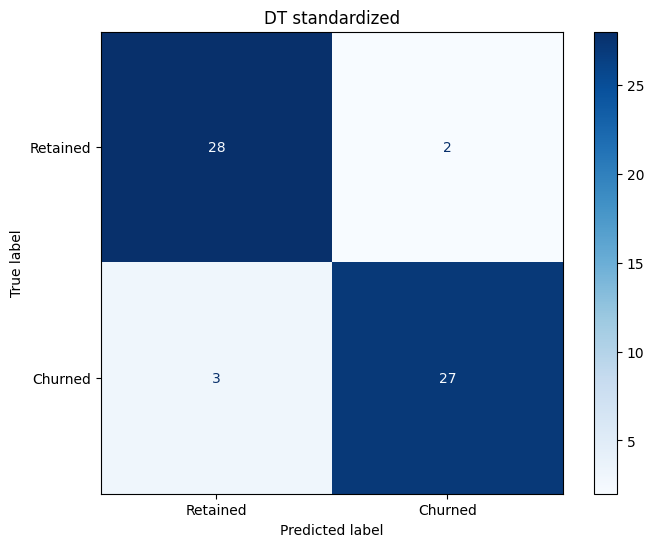

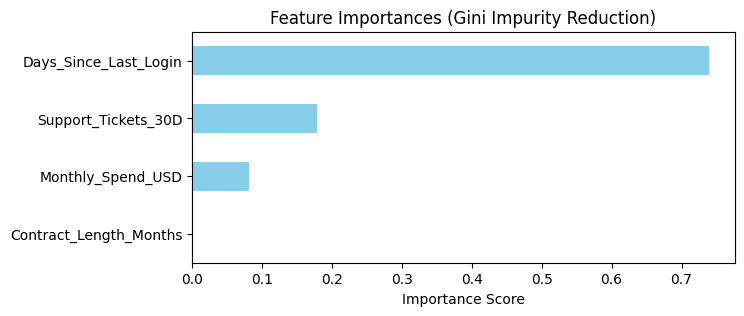


Training Accuracy: 99.29%
Testing Accuracy:  91.67%
Tree Depth: 4 | Total Leaves: 7

=== DECISION TREE RULES ===
|--- Days_Since_Last_Login <= -0.42
|   |--- Support_Tickets_30D <= 0.16
|   |   |--- Monthly_Spend_USD <= -0.66
|   |   |   |--- class: 1
|   |   |--- Monthly_Spend_USD >  -0.66
|   |   |   |--- class: 0
|   |--- Support_Tickets_30D >  0.16
|   |   |--- class: 1
|--- Days_Since_Last_Login >  -0.42
|   |--- Monthly_Spend_USD <= 0.88
|   |   |--- Days_Since_Last_Login <= -0.22
|   |   |   |--- Days_Since_Last_Login <= -0.34
|   |   |   |   |--- class: 1
|   |   |   |--- Days_Since_Last_Login >  -0.34
|   |   |   |   |--- class: 0
|   |   |--- Days_Since_Last_Login >  -0.22
|   |   |   |--- class: 1
|   |--- Monthly_Spend_USD >  0.88
|   |   |--- class: 0



In [56]:
TARGET = 'Churn'

FEATURES_X = [
    'Monthly_Spend_USD',
    'Support_Tickets_30D',
    'Days_Since_Last_Login',
    'Contract_Length_Months',
]

X, y = df_skewed[FEATURES_X], df_skewed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3, stratify=y)

pipeline_scaled = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('decisiontree',DecisionTreeClassifier(max_depth=4, random_state=42,criterion='gini'))
])

pipeline_scaled.fit(X_train, y_train)
pipeline_scaled.predict((X_test))
y_pred = pipeline_scaled.predict(X_test)

print('-------Report-------')
print(classification_report(y_test, y_pred,target_names=['Retained', 'Churned']))

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned'],
).plot(ax=ax, cmap='Blues')

plt.title('DT standardized')
plt.show()


# Feature importance
tree_model = pipeline_scaled.named_steps['decisiontree']
importances = pd.Series(
    tree_model.feature_importances_,
    index=FEATURES_X
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
importances.plot(kind='barh', color='skyblue', ax=ax)
ax.invert_yaxis()
plt.title('Feature Importances (Gini Impurity Reduction)')
plt.xlabel('Importance Score')
plt.show()

# Overfitting inspect
train_acc = pipeline_scaled.score(X_train, y_train)
test_acc = pipeline_scaled.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy:  {test_acc:.2%}")
print(f"Tree Depth: {tree_model.get_depth()} | Total Leaves: {tree_model.get_n_leaves()}")

print("\n=== DECISION TREE RULES ===")
print(export_text(tree_model, feature_names=FEATURES_X))

Similar to df_outliers, df_skewed demostrates that a skewed feature distributions do not negatively impact decision tree

# df Xor

-------Report-------
              precision    recall  f1-score   support

    Retained       0.94      0.97      0.95        30
     Churned       0.97      0.93      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



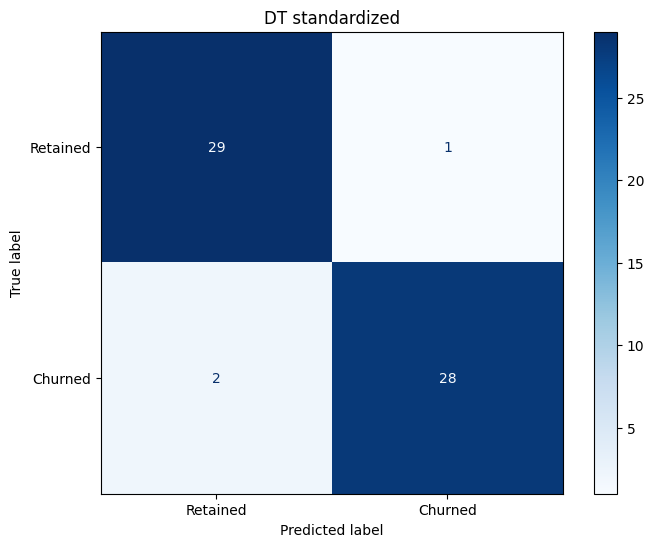

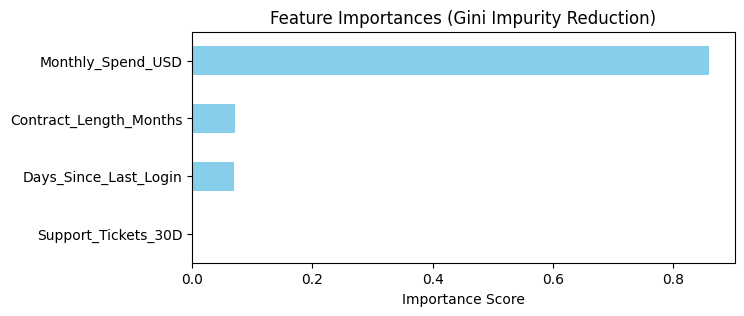


Training Accuracy: 93.57%
Testing Accuracy:  95.00%
Tree Depth: 3 | Total Leaves: 8

=== DECISION TREE RULES ===
|--- Contract_Length_Months <= -0.24
|   |--- Monthly_Spend_USD <= -0.45
|   |   |--- Days_Since_Last_Login <= 1.54
|   |   |   |--- class: 1
|   |   |--- Days_Since_Last_Login >  1.54
|   |   |   |--- class: 0
|   |--- Monthly_Spend_USD >  -0.45
|   |   |--- Days_Since_Last_Login <= 1.55
|   |   |   |--- class: 0
|   |   |--- Days_Since_Last_Login >  1.55
|   |   |   |--- class: 1
|--- Contract_Length_Months >  -0.24
|   |--- Monthly_Spend_USD <= -0.40
|   |   |--- Contract_Length_Months <= 0.89
|   |   |   |--- class: 0
|   |   |--- Contract_Length_Months >  0.89
|   |   |   |--- class: 0
|   |--- Monthly_Spend_USD >  -0.40
|   |   |--- Days_Since_Last_Login <= -1.37
|   |   |   |--- class: 1
|   |   |--- Days_Since_Last_Login >  -1.37
|   |   |   |--- class: 1



In [62]:
TARGET = 'Churn'

FEATURES_X = [
    'Monthly_Spend_USD',
    'Support_Tickets_30D',
    'Days_Since_Last_Login',
    'Contract_Length_Months',
]

X, y = df_xor[FEATURES_X], df_xor[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X,y, random_state=42, test_size=0.3, stratify=y)

pipeline_scaled = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ('decisiontree',DecisionTreeClassifier(max_depth=3, max_features=4, random_state=42))
])

pipeline_scaled.fit(X_train, y_train)
pipeline_scaled.predict((X_test))
y_pred = pipeline_scaled.predict(X_test)

print('-------Report-------')
print(classification_report(y_test, y_pred,target_names=['Retained', 'Churned']))

fig, ax = plt.subplots(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Retained', 'Churned'],
).plot(ax=ax, cmap='Blues')

plt.title('DT standardized')
plt.show()


# Feature importance
tree_model = pipeline_scaled.named_steps['decisiontree']
importances = pd.Series(
    tree_model.feature_importances_,
    index=FEATURES_X
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
importances.plot(kind='barh', color='skyblue', ax=ax)
ax.invert_yaxis()
plt.title('Feature Importances (Gini Impurity Reduction)')
plt.xlabel('Importance Score')
plt.show()

# Overfitting inspect
train_acc = pipeline_scaled.score(X_train, y_train)
test_acc = pipeline_scaled.score(X_test, y_test)

print(f"\nTraining Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy:  {test_acc:.2%}")
print(f"Tree Depth: {tree_model.get_depth()} | Total Leaves: {tree_model.get_n_leaves()}")

print("\n=== DECISION TREE RULES ===")
print(export_text(tree_model, feature_names=FEATURES_X))